In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import holidays
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, r2_score

In [ ]:
def get_dc_holidays(years):
    dc_holidays = holidays.US(state='DC', years=years)
    return dc_holidays

def calculate_weather_score(row):
    score = 100
    wind = row['windspeed']
    if wind > 20:
        score -= (wind - 20) * 2.5

    weather_penalties = {1: 0, 2: 15, 3: 50, 4: 100}
    score -= weather_penalties.get(row['weathersit'], 0)
    return max(0, min(100, round(score, 1)))

def data_alter(df):
    df['date'] = pd.to_datetime(df['dteday'])
    years = df['date'].dt.year.unique().tolist()
    dc_holiday_list = get_dc_holidays(years)
    df['is_official_holiday'] = df['date'].apply(lambda x: 1 if x in dc_holiday_list else 0)

    def mark_thanksgiving_period(row):
        d = row['date']
        if d.month == 11:
            thursdays = [day for day in range(22, 29) if datetime.date(d.year, 11, day).weekday() == 3]
            tg_day = thursdays[0]
            if tg_day <= d.day <= tg_day + 3:
                return 1
        return 0
    df['is_thanksgiving_period'] = df.apply(mark_thanksgiving_period, axis=1)

    df['is_winter_break'] = df['date'].apply(lambda x: 1 if (x.month == 12 and x.day >= 24) or (x.month == 1 and x.day <= 2) else 0)

    df['real_workingday'] = df.apply(lambda x: 1 if (x['workingday'] == 1 and
                                                   x['is_official_holiday'] == 0 and
                                                   x['is_thanksgiving_period'] == 0 and
                                                   x['is_winter_break'] == 0) else 0, axis=1)

    df['cos_month'] = np.cos(2 * np.pi * df['date'].dt.month / 12)
    df['sin_month'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
    df['sin_day'] = np.sin(2 * np.pi * df['date'].dt.weekday / 7)
    df['cos_day'] = np.cos(2 * np.pi * df['date'].dt.weekday / 7)
    df['sin_hour'] = np.sin(2 * np.pi * df['hr'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hr'] / 24)

    df['weather_rating'] = df.apply(calculate_weather_score, axis=1)
    df['weather_workday_interaction'] = df['weather_rating'] * df['real_workingday']

    df['temp_hum_interaction'] = df['temp_c'] * df['hum']

    df['is_peak'] = df.apply(lambda x: 1 if (x['real_workingday'] == 1 and
                                           x['weathersit'] < 3 and
                                           (7 <= x['hr'] <= 9 or 15 <= x['hr'] <= 19)) else 0, axis=1)

    df['years_open'] = (df['date'] - pd.to_datetime('2011-01-01')).dt.days / 365.25

    start_date = '2020-03-11'
    end_date = '2023-05-11'

    df['is_covid'] = ((df['date'] >= start_date) & (df['date'] <= end_date)).astype(int)

    df = df.drop(columns=['dteday', 'season', 'date', 'hr', 'workingday',
                          'real_workingday', 'is_official_holiday', 'feels_like_c'])
    return df

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv')
df = data_alter(df)
# df = pd.get_dummies(df, columns=['business_period', 'weathersit'])
df = pd.get_dummies(df, columns=['weathersit'])

X = df.drop(columns=['casual', 'registered'])
y_c = df['casual']
y_r = df['registered']

In [ ]:
X_train, X_temp, y_train_c, y_temp_c, y_train_r, y_temp_r = train_test_split(
    X, y_c, y_r, test_size=0.2, random_state=42
)

X_val, X_test, y_val_c, y_test_c, y_val_r, y_test_r = train_test_split(
    X_temp, y_temp_c, y_temp_r, test_size=0.5, random_state=42
)

scaler = MinMaxScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
BATCH_SIZE = 1024

def prepare_dataset(X_data, y_c_data, y_r_data, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (X_data, {"casual_output": y_c_data, "registered_output": y_r_data})
    )
    if shuffle:
        dataset = dataset.shuffle(50000)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = prepare_dataset(X_train, y_train_c, y_train_r, shuffle=True)
val_ds = prepare_dataset(X_val, y_val_c, y_val_r)


In [ ]:
def build_multi_output_model(input_dim):
    inputs = layers.Input(shape=(input_dim,), name='main_input')

    shared = layers.Dense(256, activation='relu')(inputs)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Dropout(0.3)(shared)
    shared = layers.Dense(128, activation='relu')(shared)
    shared = layers.BatchNormalization()(shared)

    c_branch = layers.Dense(64, activation='relu')(shared)
    c_out = layers.Dense(1, activation='linear', name='casual_output')(c_branch)

    r_branch = layers.Dense(64, activation='relu')(shared)
    r_out = layers.Dense(1, activation='linear', name='registered_output')(r_branch)

    model = models.Model(inputs=inputs, outputs=[c_out, r_out])

    model.compile(
        optimizer=optimizers.Adam(0.001),
        loss={
            'casual_output': 'mse',
            'registered_output': 'mse'
        },
        loss_weights={
            'casual_output': 1.2,
            'registered_output': 1.0
        },
        metrics={
            'casual_output': 'mae',
            'registered_output': 'mae'
        }
    )
    return model

with tf.device('/GPU:0'):
    model = build_multi_output_model(X_train.shape[1])

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 256)       │      5,888 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 128)       │     32,896 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_21[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ casual_output       │ (None, 1)         │         65 │ dense_22[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ registered_output   │ (None, 1)         │         65 │ dense_23[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,962 (222.51 KB)

 Trainable params: 56,194 (219.51 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1000,
    callbacks=[early_stop]
)

Epoch 1/1000
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - casual_output_loss: 18632.3105 - casual_output_mae: 77.2132 - loss: 132790.3750 - registered_output_loss: 110374.9297 - registered_output_mae: 230.1370 - val_casual_output_loss: 19978.1797 - val_casual_output_mae: 78.5473 - val_loss: 135496.7812 - val_registered_output_loss: 111498.6953 - val_registered_output_mae: 231.1890
Epoch 2/1000
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - casual_output_loss: 7212.9551 - casual_output_mae: 50.6788 - loss: 51387.8320 - registered_output_loss: 42695.7344 - registered_output_mae: 134.1970 - val_casual_output_loss: 10807.5742 - val_casual_output_mae: 55.9269 - val_loss: 55154.0000 - val_registered_output_loss: 42168.8867 - val_registered_output_mae: 121.1241
Epoch 3/1000
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - casual_output_loss: 4173.9502 - casual_output_mae: 38.3646 - loss: 20550.5020 - registered_output_loss: 15534.8242 - registered_output_mae: 81.5944 - val_casual_output_loss: 8937.7021 - val

In [ ]:
hist = pd.DataFrame(history.history)
hist = hist.reset_index()

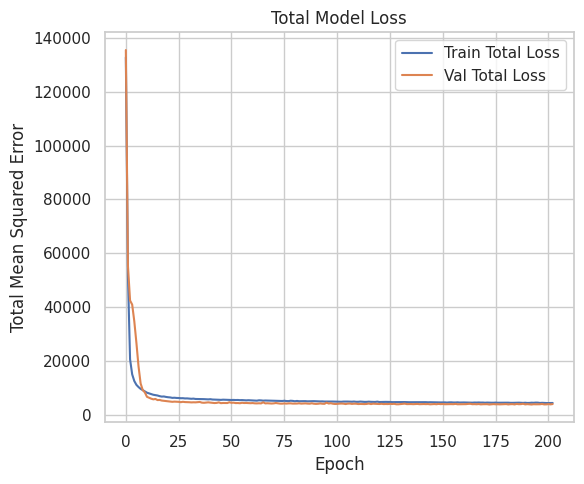

In [ ]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(6, 5))

    plt.xlabel('Epoch')
    plt.ylabel('Total Mean Squared Error')
    plt.plot(hist['epoch'], hist['loss'], label='Train Total Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='Val Total Loss')
    plt.title('Total Model Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
preds = model.predict(X_val)
pred_c = np.maximum(0, preds[0].flatten())
pred_r = np.maximum(0, preds[1].flatten())

total_val_prediction = pred_c + pred_r
actual_val_total = y_val_c + y_val_r

final_r2 = r2_score(actual_val_total, total_val_prediction)
final_rmse = root_mean_squared_error(actual_val_total, total_val_prediction)

print(f"\nR2 Score: {final_r2:.4f}")
print(f"RMSE: {final_rmse:.2f}")

352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

R2 Score: 0.9613
RMSE: 67.56


In [ ]:
preds = model.predict(X_test)
pred_c = np.maximum(0, preds[0].flatten())
pred_r = np.maximum(0, preds[1].flatten())

total_test_prediction = pred_c + pred_r
actual_test_total = y_test_c + y_test_r

final_r2 = r2_score(actual_test_total, total_test_prediction)
final_rmse = root_mean_squared_error(actual_test_total, total_test_prediction)

print(f"\nR2 Score: {final_r2:.4f}")
print(f"RMSE: {final_rmse:.2f}")

352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

R2 Score: 0.9604
RMSE: 68.12


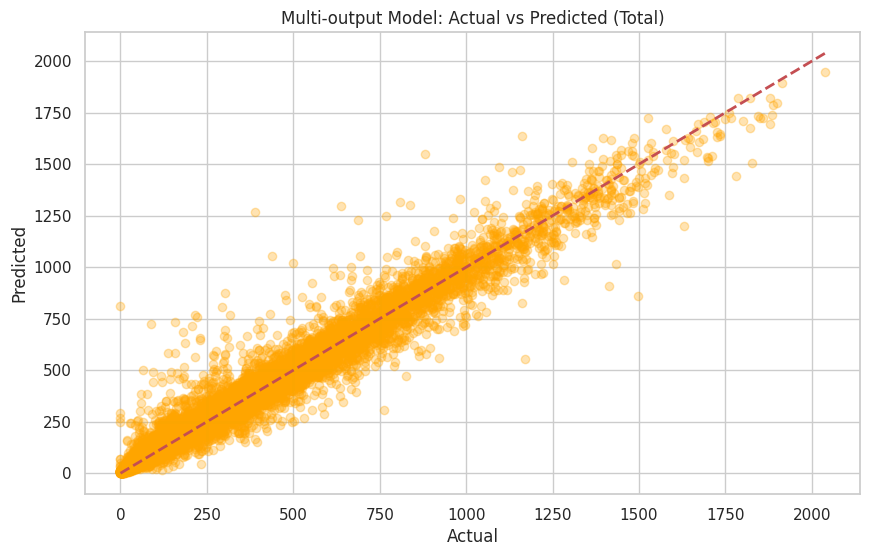

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(actual_test_total, total_test_prediction, alpha=0.3, color='orange')
plt.plot([actual_test_total.min(), actual_test_total.max()], [actual_test_total.min(), actual_test_total.max()], 'r--', lw=2)
plt.title('Multi-output Model: Actual vs Predicted (Total)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [ ]:
hold = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/biking_holdout_test_mini.csv')
hold = data_alter(hold)

hold = pd.get_dummies(hold, columns=['weathersit'])

model_columns = list(X.columns)
hold = hold.reindex(columns=model_columns, fill_value=False)

hold_scaled = scaler.transform(hold)

preds = model.predict(hold_scaled)

total_hold_pred = np.maximum(0, preds[0].flatten()) + np.maximum(0, preds[1].flatten())
total_hold_pred = np.round(total_hold_pred).astype(int)

output = pd.DataFrame(total_hold_pred, columns=['predictions'])
output.to_csv('team3-module4-predictions.csv', index=False, header=True)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


/tmp/ipykernel_1411797/3806128809.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


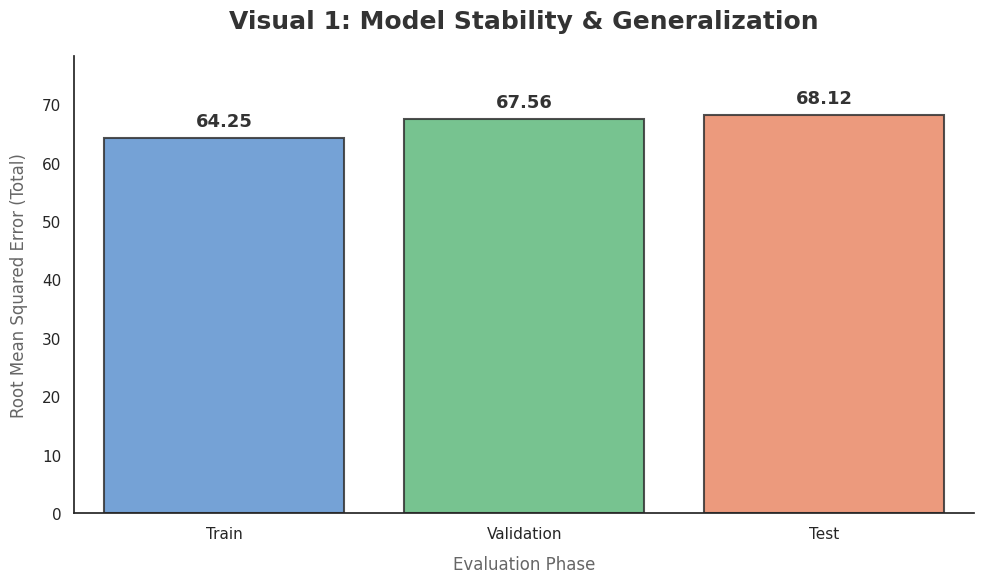

In [ ]:

def get_rmse(X_data, y_c, y_r):
    p = model.predict(X_data, verbose=0)
    p_total = np.maximum(0, p[0].flatten()) + np.maximum(0, p[1].flatten())
    return root_mean_squared_error(y_c + y_r, p_total)

metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'RMSE': [get_rmse(X_train, y_train_c, y_train_r),
             get_rmse(X_val, y_val_c, y_val_r),
             get_rmse(X_test, y_test_c, y_test_r)]
})

sns.set_style("white")
plt.figure(figsize=(10, 6), dpi=100)

colors = ["#4A90E2", "#50C878", "#FF7F50"]

ax = sns.barplot(
    x='Dataset', y='RMSE', data=metrics_df,
    palette=colors, alpha=0.85, edgecolor=".2", linewidth=1.5
)

sns.despine()

plt.title('Visual 1: Model Stability & Generalization', fontsize=18, pad=20, fontweight='bold', color='#333333')
plt.xlabel('Evaluation Phase', fontsize=12, labelpad=10, color='#666666')
plt.ylabel('Root Mean Squared Error (Total)', fontsize=12, labelpad=10, color='#666666')

for i, v in enumerate(metrics_df['RMSE']):
    ax.text(
        i, v + (metrics_df['RMSE'].max() * 0.02),
        f"{v:.2f}",
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#333333'
    )

plt.ylim(0, metrics_df['RMSE'].max() * 1.15)

plt.tight_layout()
plt.show()

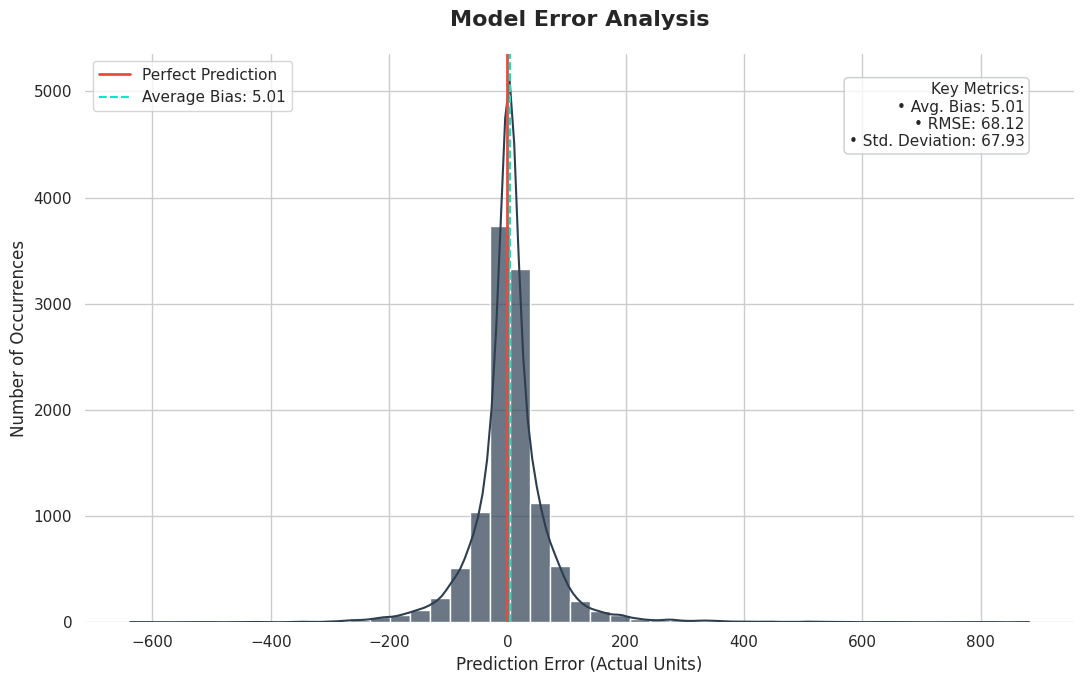

In [ ]:

def residuals_plot_pro(y_actual, y_pred, model_name="Model"):
    """
    Creates an executive-level error distribution chart.
    Shows the frequency of errors and key business metrics.
    """
    residuals = y_pred - y_actual

    # Calculate key metrics for the summary box
    mean_err = np.mean(residuals)
    mae = np.mean(np.abs(residuals))
    rmse = root_mean_squared_error(y_actual, y_pred)
    std_err = np.std(residuals)

    # Styling
    sns.set_theme(style="whitegrid", palette="muted")
    plt.figure(figsize=(11, 7))

    # Main Distribution
    ax = sns.histplot(residuals, kde=True, color='#2c3e50', bins=45, alpha=0.7)

    # Zero Error Reference Line
    plt.axvline(x=0, color='#e74c3c', linestyle='-', linewidth=2, label='Perfect Prediction')

    # Add Mean Error Line (Bias Indicator)
    plt.axvline(x=mean_err, color='#08e6c8', linestyle='--', linewidth=1.5, label=f'Average Bias: {mean_err:.2f}')

    # Create the Summary Statistics Box
    stats_text = (
        f"Key Metrics:\n"
        f"• Avg. Bias: {mean_err:.2f}\n"
        f"• RMSE: {rmse:.2f}\n"
        f"• Std. Deviation: {std_err:.2f}"
    )

    # Place text box in the upper right
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#bdc3c7')
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    # Titles and Labels
    plt.title(f'{model_name} Error Analysis', fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Prediction Error (Actual Units)', fontsize=12)
    plt.ylabel('Number of Occurrences', fontsize=12)
    plt.legend(loc='upper left')

    # Clean up layout
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

# Call with your data
residuals_plot_pro(actual_test_total, total_test_prediction)

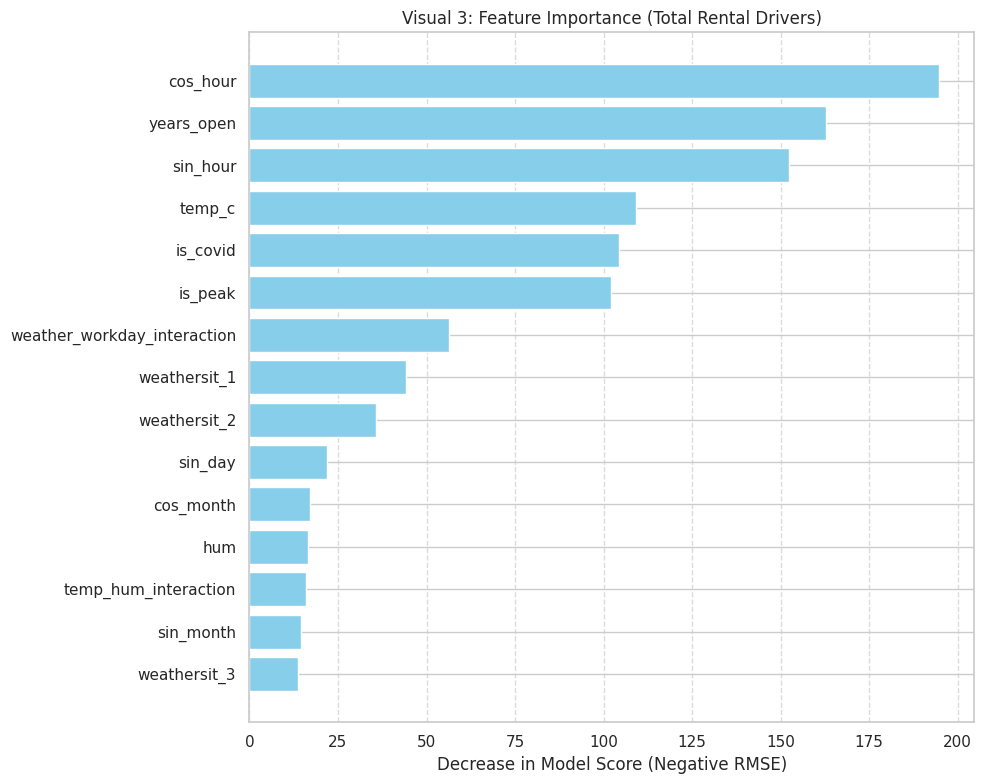

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

def custom_total_rmse(estimator, X_val_scaled, y_true_combined):
    p = estimator.predict(X_val_scaled, verbose=0)
    p_total = np.maximum(0, p[0].flatten()) + np.maximum(0, p[1].flatten())
    return -root_mean_squared_error(y_true_combined, p_total)

y_test_combined = y_test_c + y_test_r

results = permutation_importance(
    model,
    X_test[:1000],
    y_test_combined[:1000],
    scoring=custom_total_rmse,
    n_repeats=5,
    random_state=42
)

sorted_idx = results.importances_mean.argsort()[-15:]
plt.figure(figsize=(10, 8))
plt.barh(X.columns[sorted_idx], results.importances_mean[sorted_idx], color='skyblue')
plt.title('Visual 3: Feature Importance (Total Rental Drivers)')
plt.xlabel('Decrease in Model Score (Negative RMSE)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

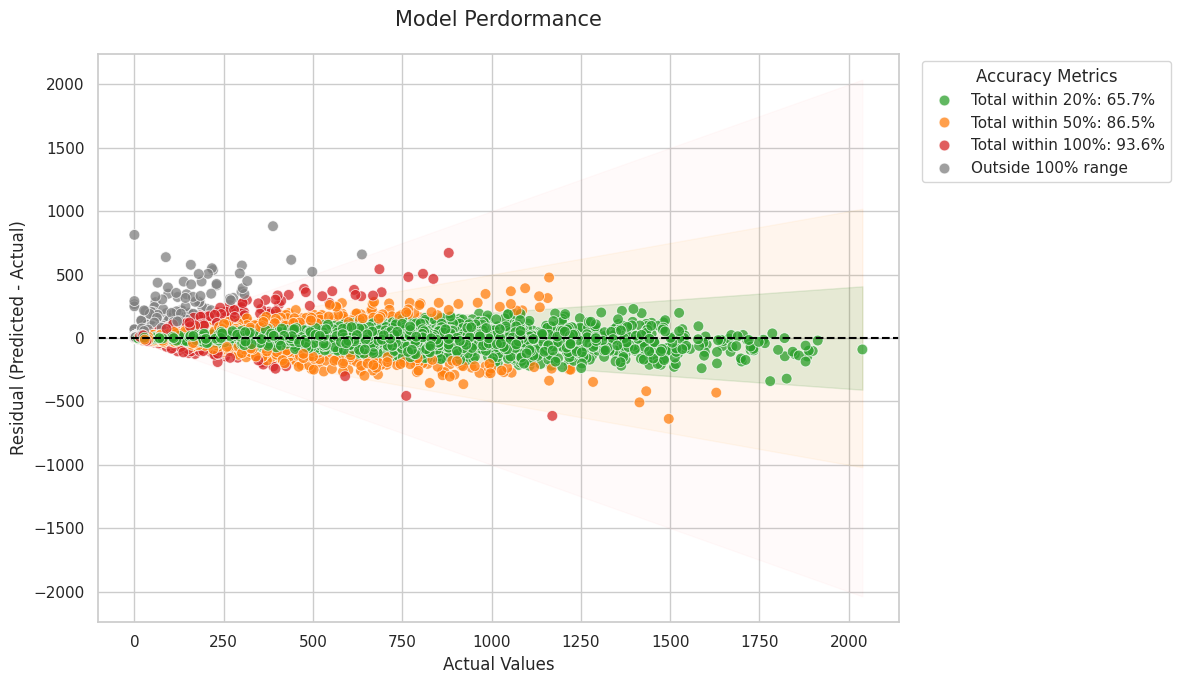

In [ ]:
def plot_residuals_cumulative(actual, predicted, title="Cumulative Residual Analysis"):

    actual = np.array(actual)
    predicted = np.array(predicted)

    residuals = predicted - actual
    with np.errstate(divide='ignore', invalid='ignore'):
        percent_error = np.abs(residuals / actual)

    total_count = len(actual)

    # 1. Calculate Cumulative Percentages
    # These represent "Total within X%"
    pct_20 = (percent_error <= 0.20).sum() / total_count * 100
    pct_50 = (percent_error <= 0.50).sum() / total_count * 100
    pct_100 = (percent_error <= 1.00).sum() / total_count * 100

    # 2. Assign categories for the scatter plot points (the visual dots)
    # Note: Dots are colored by their 'best' fit category to avoid overlapping colors
    categories = []
    for error in percent_error:
        if error <= 0.20:
            categories.append('Within 20%')
        elif error <= 0.50:
            categories.append('Within 50%')
        elif error <= 1.00:
            categories.append('Within 100%')
        else:
            categories.append('> 100% Error')

    # 3. Map to cumulative legend labels
    label_map = {
        'Within 20%': f'Total within 20%: {pct_20:.1f}%',
        'Within 50%': f'Total within 50%: {pct_50:.1f}%',
        'Within 100%': f'Total within 100%: {pct_100:.1f}%',
        '> 100% Error': f'Outside 100% range'
    }

    df = pd.DataFrame({
        'Actual': actual,
        'Residual': residuals,
        'Legend': [label_map[cat] for cat in categories]
    })

    # 4. Set up Hue Order and Palette
    hue_order = [label_map['Within 20%'], label_map['Within 50%'], label_map['Within 100%'], label_map['> 100% Error']]
    palette = {
        label_map['Within 20%']: '#2ca02c', # Green
        label_map['Within 50%']: '#ff7f0e', # Orange
        label_map['Within 100%']: '#d62728', # Red
        label_map['> 100% Error']: '#7f7f7f' # Gray (FIXED: Changed key from 'Outside 100% range' to '> 100% Error')
    }

    # 5. Build the Plot
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # Background Bands for visual context
    x_range = np.linspace(actual.min(), actual.max(), 100)
    plt.fill_between(x_range, -0.20 * x_range, 0.20 * x_range, color='green', alpha=0.1)
    plt.fill_between(x_range, -0.50 * x_range, 0.50 * x_range, color='orange', alpha=0.05)
    plt.fill_between(x_range, -1.00 * x_range, 1.00 * x_range, color='red', alpha=0.02)

    # Scatter points
    sns.scatterplot(
        data=df, x='Actual', y='Residual', hue='Legend',
        hue_order=hue_order, palette=palette, alpha=0.75, s=60, edgecolor='w'
    )

    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
    plt.title(title, fontsize=15, pad=20)
    plt.xlabel('Actual Values', fontsize=12)
    plt.ylabel('Residual (Predicted - Actual)', fontsize=12)
    plt.legend(title='Accuracy Metrics', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



plot_residuals_cumulative(actual_test_total, total_test_prediction, "Model Perdormance")

In [ ]:
hold = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes_december.csv')
hold = data_alter(hold)

hold = pd.get_dummies(hold, columns=['weathersit'])

model_columns = list(X.columns)
hold = hold.reindex(columns=model_columns, fill_value=False)

hold_scaled = scaler.transform(hold)

preds = model.predict(hold_scaled)

total_hold_pred = np.maximum(0, preds[0].flatten()) + np.maximum(0, preds[1].flatten())
total_hold_pred = np.round(total_hold_pred).astype(int)

output = pd.DataFrame(total_hold_pred, columns=['predictions'])
output.to_csv('team3-module4-predictions.csv', index=False, header=True)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
